# Modeling Component Area, Energy, Latency, and Leak Power

This notebook shows how to integrate component models from the `hwcomponents` library to
model area, energy, latency, and leak power.

Before reading this notebook, you should be familiar with the `hwcomponents` library.
Ensure you've installed it and been through all of the notebooks in the [hwcomponents
documentation](https://accelergy-project.github.io/hwcomponents/).

We'll be using the `component_example.yaml` file, which is annotated explaining what
each attribute means.

In [1]:
import accelforge as af

# Standard eDRAM
baseline_component = af.arch.Memory.from_yaml("baseline_test.yaml")
baseline_component = baseline_component.calculate_area_energy_latency_leak()


# 333-eDRAM
edram333_component = af.arch.Memory.from_yaml("edram333_test.yaml")
edram333_component = edram333_component.calculate_area_energy_latency_leak()

print("==========================================================")
print(f"--- {baseline_component.name} (Standard Stacked 3D) ---")
print(f"Area: {baseline_component.area:.2e} m^2")
print(f"Leak power: {baseline_component.leak_power:.2e} W")
for action in baseline_component.actions:
    print(f"Action {action.name} energy: {action.energy:.2e} J, latency: {action.latency:.2e} s")

print("\n==========================================================")
print(f"--- {edram333_component.name} (333-eDRAM Monolithic 3D) ---")
print(f"Area: {edram333_component.area:.2e} m^2")
print(f"Leak power: {edram333_component.leak_power:.2e} W")
for action in edram333_component.actions:
    print(f"Action {action.name} energy: {action.energy:.2e} J, latency: {action.latency:.2e} s")
print("==========================================================")

--- Baseline3DGlobalBuffer (Standard Stacked 3D) ---
Area: 1.52e-06 m^2
Leak power: 1.53e-01 W
Action read energy: 7.00e-11 J, latency: 4.05e-10 s
Action write energy: 6.80e-11 J, latency: 1.45e-10 s

--- 333GlobalBuffer (333-eDRAM Monolithic 3D) ---
Area: 4.29e-07 m^2
Leak power: 1.77e-02 W
Action read energy: 2.36e-11 J, latency: 2.03e-10 s
Action write energy: 2.30e-11 J, latency: 1.06e-10 s


In [2]:
for message in edram333_component.component_modeling_log:
    print(message)

Initializing EDRAM_333_Cache from hwcomponents_cacti.hwcomponents_cacti
Calling __init__ with arguments {'size': 1048576, 'width': 128}
Unused arguments for ['edram333_cache', '333edram_cache'].__init__: (actions, area_scale, bits_per_value, component_class, component_modeling_log, enabled, energy_scale, extra_attributes_for_component_model, latency_scale, leak_power_scale, n_parallel_instances, name, skip_initial_output_write, spatial, tensors, total_latency) Arguments used: (size, width)
Running DESTINY: /Users/Rishi/Documents/Harvard/6/6.5930/project/hwcomponents-333e/hwcomponents_cacti/destiny_3d_cache/destiny 149cdcb88fbdcf2c54a9b841117e4337c157b84a8b5ffd68046361df8ca8d85d.cfg
DESTINY returned read lat 3.3000000000000005e-10, write lat 1.3800000000000001e-10
DESTINY returned read eng 3.7e-11, write eng 3.6e-11
DESTINY returned leak 0.17287200000000003, area 4.29e-07
Calculating energy for 333GlobalBuffer action read.

Calling action EDRAM_333_Cache.read with arguments () and {'bit

As we can see in the doc, this function also fills out the `component_modeling_log`
attribute of the component, which contains messages from the component modeling
calculations.

To get more details on the specific model used, we can also look at the
`component_model` attribute of the component, which has the
`hwcomponents.ComponentModel` object that was used to calculate the energy and area. We
can use `help()` on this object to get more details on the model.

Now we'll model the components for a larger design using the `eyeriss`
architecture.

The top-level specification object has a `calculate_area_energy_latency_leak` method
that can be used to calculate the area, energy, latency, and leak power of all
components in the design. Additionally, when called from the top-level specification,
this method parses expressions in the architecture, letting you express attributes as
functions of other attributes.

In [4]:
# < DOC_INCLUDE_MARKER > spec_energy_area

# Load the spec and calculate the energy and area of the entire design
spec = af.Spec.from_yaml("eyeriss_baseline.yaml")
spec = spec.calculate_component_area_energy_latency_leak()

# Print out the total area and leakage power of the entire design
print(f'Total area of the design: {spec.arch.total_area:.2e} m^2')
print(f'Area breakdown per component:')
for component, area in spec.arch.per_component_total_area.items():
    print(f'\t{component}: {area:.2e} m^2')
print(f'Total leakage power of the design: {spec.arch.total_leak_power:.2e} W')
for component, leak_power in spec.arch.per_component_total_leak_power.items():
    print(f'\t{component}: {leak_power:.2e} W')

Total area of the design: 4.31e-06 m^2
Area breakdown per component:
	MainMemory: 0.00e+00 m^2
	GlobalBuffer: 7.17e-07 m^2
	InputScratchpad: 1.18e-06 m^2
	WeightScratchpad: 1.18e-06 m^2
	OutputScratchpad: 1.18e-06 m^2
	MAC: 6.49e-08 m^2
Total leakage power of the design: 6.29e-01 W
	MainMemory: 0.00e+00 W
	GlobalBuffer: 6.83e-02 W
	InputScratchpad: 1.87e-01 W
	WeightScratchpad: 1.87e-01 W
	OutputScratchpad: 1.87e-01 W
	MAC: 7.73e-04 W


In [6]:
# Load the spec and calculate the energy and area of the entire design
spec = af.Spec.from_yaml("eyeriss_333.yaml")
spec = spec.calculate_component_area_energy_latency_leak()

# Print out the total area and leakage power of the entire design
print(f'Total area of the design: {spec.arch.total_area:.2e} m^2')
print(f'Area breakdown per component:')
for component, area in spec.arch.per_component_total_area.items():
    print(f'\t{component}: {area:.2e} m^2')
print(f'Total leakage power of the design: {spec.arch.total_leak_power:.2e} W')
for component, leak_power in spec.arch.per_component_total_leak_power.items():
    print(f'\t{component}: {leak_power:.2e} W')

Total area of the design: 2.51e-06 m^2
Area breakdown per component:
	MainMemory: 0.00e+00 m^2
	GlobalBuffer: 4.29e-07 m^2
	InputScratchpad: 6.72e-07 m^2
	WeightScratchpad: 6.72e-07 m^2
	OutputScratchpad: 6.72e-07 m^2
	MAC: 6.49e-08 m^2
Total leakage power of the design: 8.59e-02 W
	MainMemory: 0.00e+00 W
	GlobalBuffer: 1.77e-02 W
	InputScratchpad: 2.25e-02 W
	WeightScratchpad: 2.25e-02 W
	OutputScratchpad: 2.25e-02 W
	MAC: 7.73e-04 W


Once the area, energy, latency, and leak power of the architecture are calculated, we can
look at any individual component and analyze it like we analyzed the global buffer.

In [9]:
mac = spec.arch.find("MAC")
print(f'MAC area: {mac.area:.2e} m^2')
print(f'Total area of all MACs in the architecture: {mac.total_area:.2e} m^2')
print(f'MAC leak power: {mac.leak_power:.2e} W')
print(f'Total leak power of all MACs in the architecture: {mac.total_leak_power:.2e} W')
for action in mac.actions:
    print(f'{action.name} energy: {action.energy:.2e} J, latency {action.latency:.2e}s')

MAC area: 1.40e-09 m^2
Total area of all MACs in the architecture: 2.35e-07 m^2
MAC leak power: 9.73e-06 W
Total leak power of all MACs in the architecture: 1.64e-03 W
compute energy: 1.41e-12 J, latency 3.25e-09s


We can also force the design to use a specific model for a component by passing in our
own `ComponentModel` object. Here we'll create a custom MAC model that has lower
leakage power than the default model.












The `hwcomponents` library has plenty of other component models to use! These can be
listed with the `hwcomponents.get_models` function.

If you're interested in a specific model, use the `help()` function to get more
information on it.

For more information, see the [hwcomponents
documentation](https://accelergy-project.github.io/hwcomponents/).

In [6]:
import hwcomponents as hwc

for model in hwc.get_models()[:5]:
    print(f"{model} supports {model.component_name}")
    for action in model.get_action_names():
        print(f'\t{action}')


from hwcomponents_adc import ADC
help(ADC)

<class 'hwcomponents_adc.main.ADC'> supports ['adc', 'pim_adc', 'sar_adc', 'array_adc', 'pim_array_adc', 'cim_array_adc', 'cim_adc']
	activate
	convert
	drive
	read
	sample
<class 'hwcomponents_neurosim.main.ADC'> supports ['ArrayADC', 'NeuroSimArrayADC']
	add
	compute
	convert
	read
	update
	write
<class 'hwcomponents_neurosim.main.Adder'> supports ['Adder', 'NeuroSimAdder', 'IntAdder']
	add
	compute
	convert
	read
	update
	write
<class 'hwcomponents_neurosim.main.AdderTree'> supports ['AdderTree', 'NeuroSimAdderTree', 'IntAdderTree']
	add
	compute
	convert
	read
	update
	write
<class 'hwcomponents_library.library.aladdin.AladdinAdder'> supports ['Adder', 'AladdinAdder', 'IntAdder']
	add
	read
	write
Help on class ADC in module hwcomponents_adc.main:

class ADC(hwcomponents.model.ComponentModel)
 |  ADC(n_bits: int, tech_node: float, throughput: float, n_adcs=1)
 |
 |  Analog digital converter (ADC) model based on https://arxiv.org/abs/2404.06553.
 |
 |  Args:
 |      n_bits: The numb

In [9]:
spec = af.Spec.from_yaml("eyeriss_333.yaml", "gpt3_6.7B.yaml", jinja_parse_data={"BATCH_SIZE": 1, "N_TOKENS": 8192})
spec.mapper.metrics = af.mapper.Metrics.LATENCY | af.mapper.Metrics.ENERGY

mapping = spec.map_workload_to_arch()

Getting energy, latency, and leak power for components running each Einsum. : 100%|██████████| 10/10 [01:04<00:00,  6.47s/it]
Generating pmapping templates for compute MAC Einsum I: 2it [00:00, 246.92it/s]
Generating pmapping templates for compute MAC Einsum QK_softmax: 13it [00:00, 345.68it/s]
Generating pmapping templates for compute MAC Einsum FFB: 27it [00:00, 180.53it/s]
Generating pmapping templates for compute MAC Einsum Q: 46it [00:00, 197.27it/s]]
Generating pmapping templates for compute MAC Einsum K: 46it [00:00, 190.40it/s]s]
Generating pmapping templates for compute MAC Einsum V: 46it [00:00, 181.88it/s]
Generating pmapping templates for compute MAC Einsum FFA: 46it [00:00, 186.19it/s]
Generating pmapping templates for compute MAC Einsum Z: 46it [00:00, 179.01it/s]
Generating pmapping templates for compute MAC Einsum QK: 79it [00:00, 213.75it/s]
Generating pmapping templates for compute MAC Einsum AV: 79it [00:00, 216.16it/s]
Generating jobs: 100%|██████████| 10/10 [00:00<

Einsum I has 2 pmapping jobs:
	0	[I_in in MainMemory] T-b  T-d  T-m  [I in GlobalBuffer] T-b  T-d  T-m  S-reuse_weight-m  S-reuse_weight-d  S-reuse_weight-b  MAC computes I
	1	[I_in in MainMemory] [I in MainMemory] T-b  T-d  T-m  S-reuse_weight-m  S-reuse_weight-d  S-reuse_weight-b  MAC computes I
Einsum V has 46 pmapping jobs:
	0	[WV in MainMemory] T-b  T-m  [I in GlobalBuffer] T-b  T-e  T-h  T-m  [V in GlobalBuffer] T-b  T-d  T-m  S-reuse_output-d  S-reuse_weight-m  S-reuse_weight-b  [I in InputScratchpad] T-e  T-h  [WV in WeightScratchpad] T-b  T-m  [V in OutputScratchpad] T-d  MAC computes V
	1	[WV in MainMemory] T-b  T-m  [I in GlobalBuffer] T-b  T-e  T-h  T-m  [V in GlobalBuffer] T-d  T-e  T-h  [WV in GlobalBuffer] T-b  T-m  S-reuse_output-d  S-reuse_weight-m  S-reuse_weight-b  [I in InputScratchpad] T-e  T-h  [WV in WeightScratchpad] T-b  T-m  [V in OutputScratchpad] T-d  MAC computes V
	2	[WV in MainMemory] T-b  T-m  [V in GlobalBuffer] T-b  T-d  T-m  [I in GlobalBuffer] T-b  T

Compressing pmappings: 100%|██████████| 10/10 [00:00<00:00, 104.15it/s]


Dirty joining with resource usage <= 1.2× optimal
Dirty joining with objectives <= 2× optimal


Dirty pruning pmappings: 100%|██████████| 158/158 [00:00<00:00, 1936.37it/s]


...

Filtering out pmappings worse than the following:
	Total<SEP>latency=1.73e+02    Total<SEP>energy=2.09e+01
Final clean join.


Dirty pruning pmappings: 100%|██████████| 158/158 [00:00<00:00, 2569.51it/s]


Dirty joining uses 100.00% of the pmappings
Filtered 25185 -> 23450 (93.11% kept) pmappings
Not tracking MainMemory because its size is enough for the sum of all reservations (90.62% of the total)


Grouping pmappings: 100%|██████████| 1/1 [00:00<00:00, 293.16it/s]


Dirty joining mapping(s) valid & optimal! Returning...


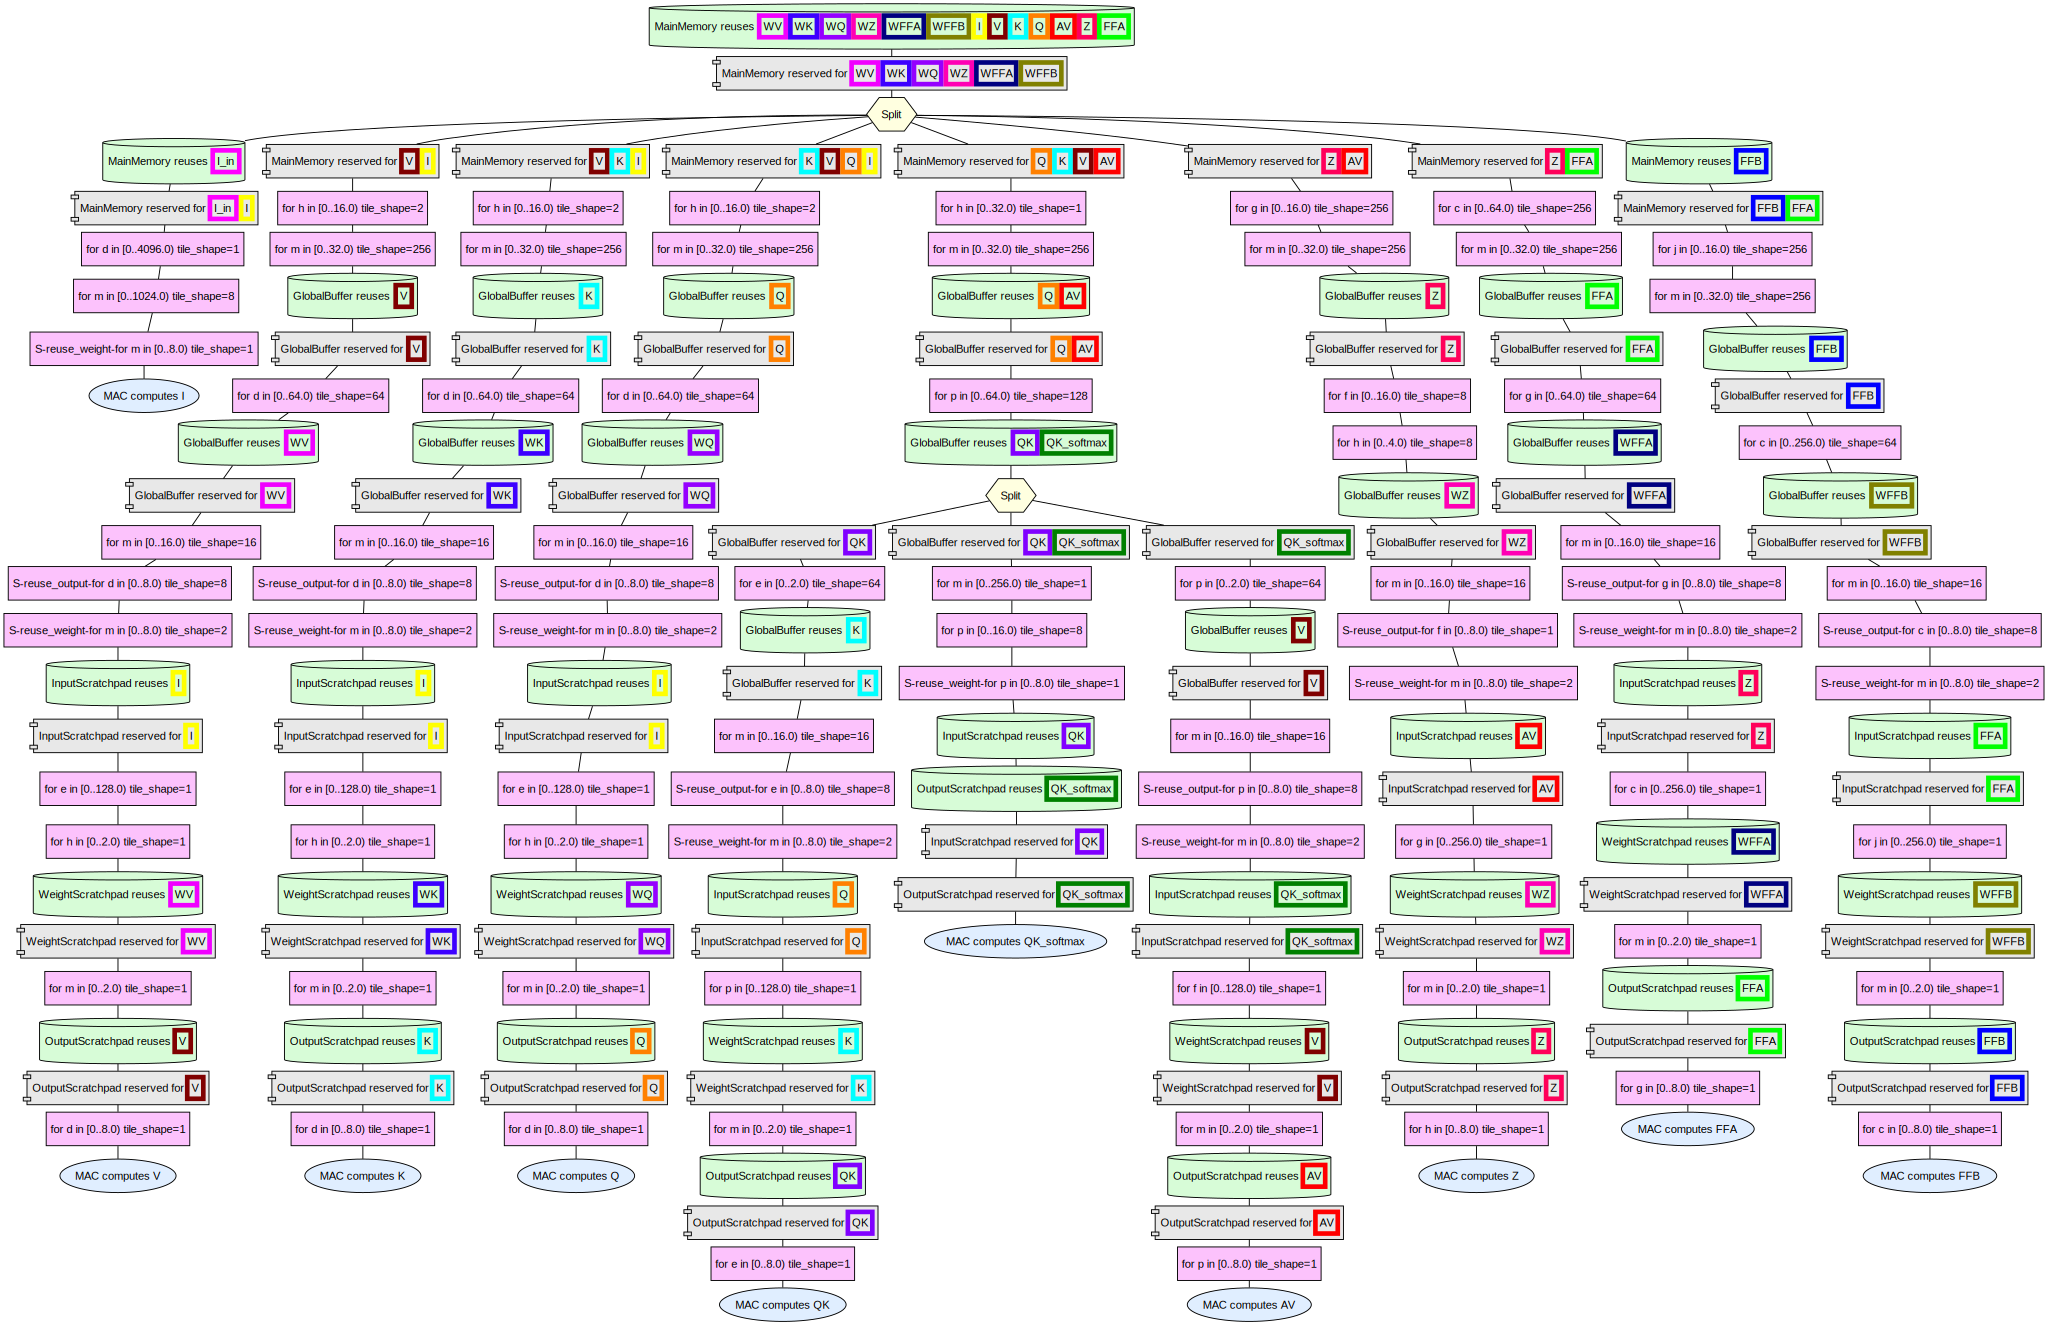

In [11]:
mapping

In [12]:
print(f'Energy: {mapping.energy()}J, {mapping.per_compute().energy()}J/compute')
for k, v in mapping.per_compute().energy(per_component=True).items():
    print(f'\t{k}: {v}J/compute')

print(f'Latency: {mapping.latency()}s, {mapping.per_compute().latency()}s/compute')
for k, v in mapping.per_compute().latency(per_component=True).items():
    print(f'\t{k}: {v}s/compute')

Energy: 19.592543788727394J, 8.900829267762293e-12J/compute
	MainMemory: 4.477980518589654e-13J/compute
	GlobalBuffer: 1.5400778752211565e-12J/compute
	InputScratchpad: 1.9691706511886967e-12J/compute
	WeightScratchpad: 2.0477747432338413e-12J/compute
	OutputScratchpad: 2.1694670368000173e-12J/compute
	MAC: 7.265409094596154e-13J/compute
Latency: 173.16183958761394s, 7.866686330923093e-11s/compute
	MainMemory: 1.6681777270308173e-11s/compute
	MAC: 7.86668646890476e-11s/compute
	InputScratchpad: 8.841558263522967e-14s/compute
	OutputScratchpad: 1.9551324263993725e-13s/compute
	GlobalBuffer: 1.962920248929132e-12s/compute
	WeightScratchpad: 1.3030410626370392e-13s/compute


In [13]:
spec2 = af.Spec.from_yaml("eyeriss_baseline.yaml", "gpt3_6.7B.yaml", jinja_parse_data={"BATCH_SIZE": 1, "N_TOKENS": 8192})
spec2.mapper.metrics = af.mapper.Metrics.LATENCY | af.mapper.Metrics.ENERGY

mapping2 = spec2.map_workload_to_arch()

Getting energy, latency, and leak power for components running each Einsum. : 100%|██████████| 10/10 [01:14<00:00,  7.49s/it]
Generating pmapping templates for compute MAC Einsum I: 2it [00:00, 407.08it/s]
Generating pmapping templates for compute MAC Einsum QK_softmax: 13it [00:00, 290.60it/s]
Generating pmapping templates for compute MAC Einsum FFB: 27it [00:00, 145.61it/s]
Generating pmapping templates for compute MAC Einsum K: 46it [00:00, 159.36it/s]s]
Generating pmapping templates for compute MAC Einsum V: 46it [00:00, 153.10it/s]
Generating pmapping templates for compute MAC Einsum Q: 46it [00:00, 148.56it/s]
Generating pmapping templates for compute MAC Einsum Z: 46it [00:00, 150.85it/s]
Generating pmapping templates for compute MAC Einsum FFA: 46it [00:00, 147.75it/s]
Generating pmapping templates for compute MAC Einsum QK: 79it [00:00, 164.54it/s]
Generating pmapping templates for compute MAC Einsum AV: 79it [00:00, 155.57it/s]
Generating jobs: 100%|██████████| 10/10 [00:00<0

Einsum I has 2 pmapping jobs:
	0	[I_in in MainMemory] T-b  T-d  T-m  [I in GlobalBuffer] T-b  T-d  T-m  S-reuse_weight-m  S-reuse_weight-d  S-reuse_weight-b  MAC computes I
	1	[I_in in MainMemory] [I in MainMemory] T-b  T-d  T-m  S-reuse_weight-m  S-reuse_weight-d  S-reuse_weight-b  MAC computes I
Einsum V has 46 pmapping jobs:
	0	[WV in MainMemory] T-b  T-m  [I in GlobalBuffer] T-b  T-e  T-h  T-m  [V in GlobalBuffer] T-b  T-d  T-m  S-reuse_output-d  S-reuse_weight-m  S-reuse_weight-b  [I in InputScratchpad] T-e  T-h  [WV in WeightScratchpad] T-b  T-m  [V in OutputScratchpad] T-d  MAC computes V
	1	[WV in MainMemory] T-b  T-m  [I in GlobalBuffer] T-b  T-e  T-h  T-m  [V in GlobalBuffer] T-d  T-e  T-h  [WV in GlobalBuffer] T-b  T-m  S-reuse_output-d  S-reuse_weight-m  S-reuse_weight-b  [I in InputScratchpad] T-e  T-h  [WV in WeightScratchpad] T-b  T-m  [V in OutputScratchpad] T-d  MAC computes V
	2	[WV in MainMemory] T-b  T-m  [V in GlobalBuffer] T-b  T-d  T-m  [I in GlobalBuffer] T-b  T

Compressing pmappings: 100%|██████████| 10/10 [00:00<00:00, 20.11it/s]


Dirty joining with resource usage <= 1.2× optimal
Dirty joining with objectives <= 2× optimal


Dirty pruning pmappings: 100%|██████████| 158/158 [00:00<00:00, 631.96it/s]


...

Filtering out pmappings worse than the following:
	Total<SEP>latency=1.73e+02    Total<SEP>energy=1.17e+02
Final clean join.


Dirty pruning pmappings: 100%|██████████| 158/158 [00:00<00:00, 659.20it/s]


Dirty joining uses 100.00% of the pmappings
Filtered 24958 -> 23247 (93.14% kept) pmappings
Not tracking MainMemory because its size is enough for the sum of all reservations (90.62% of the total)


Grouping pmappings: 100%|██████████| 1/1 [00:00<00:00, 81.20it/s]


Dirty joining mapping(s) valid & optimal! Returning...


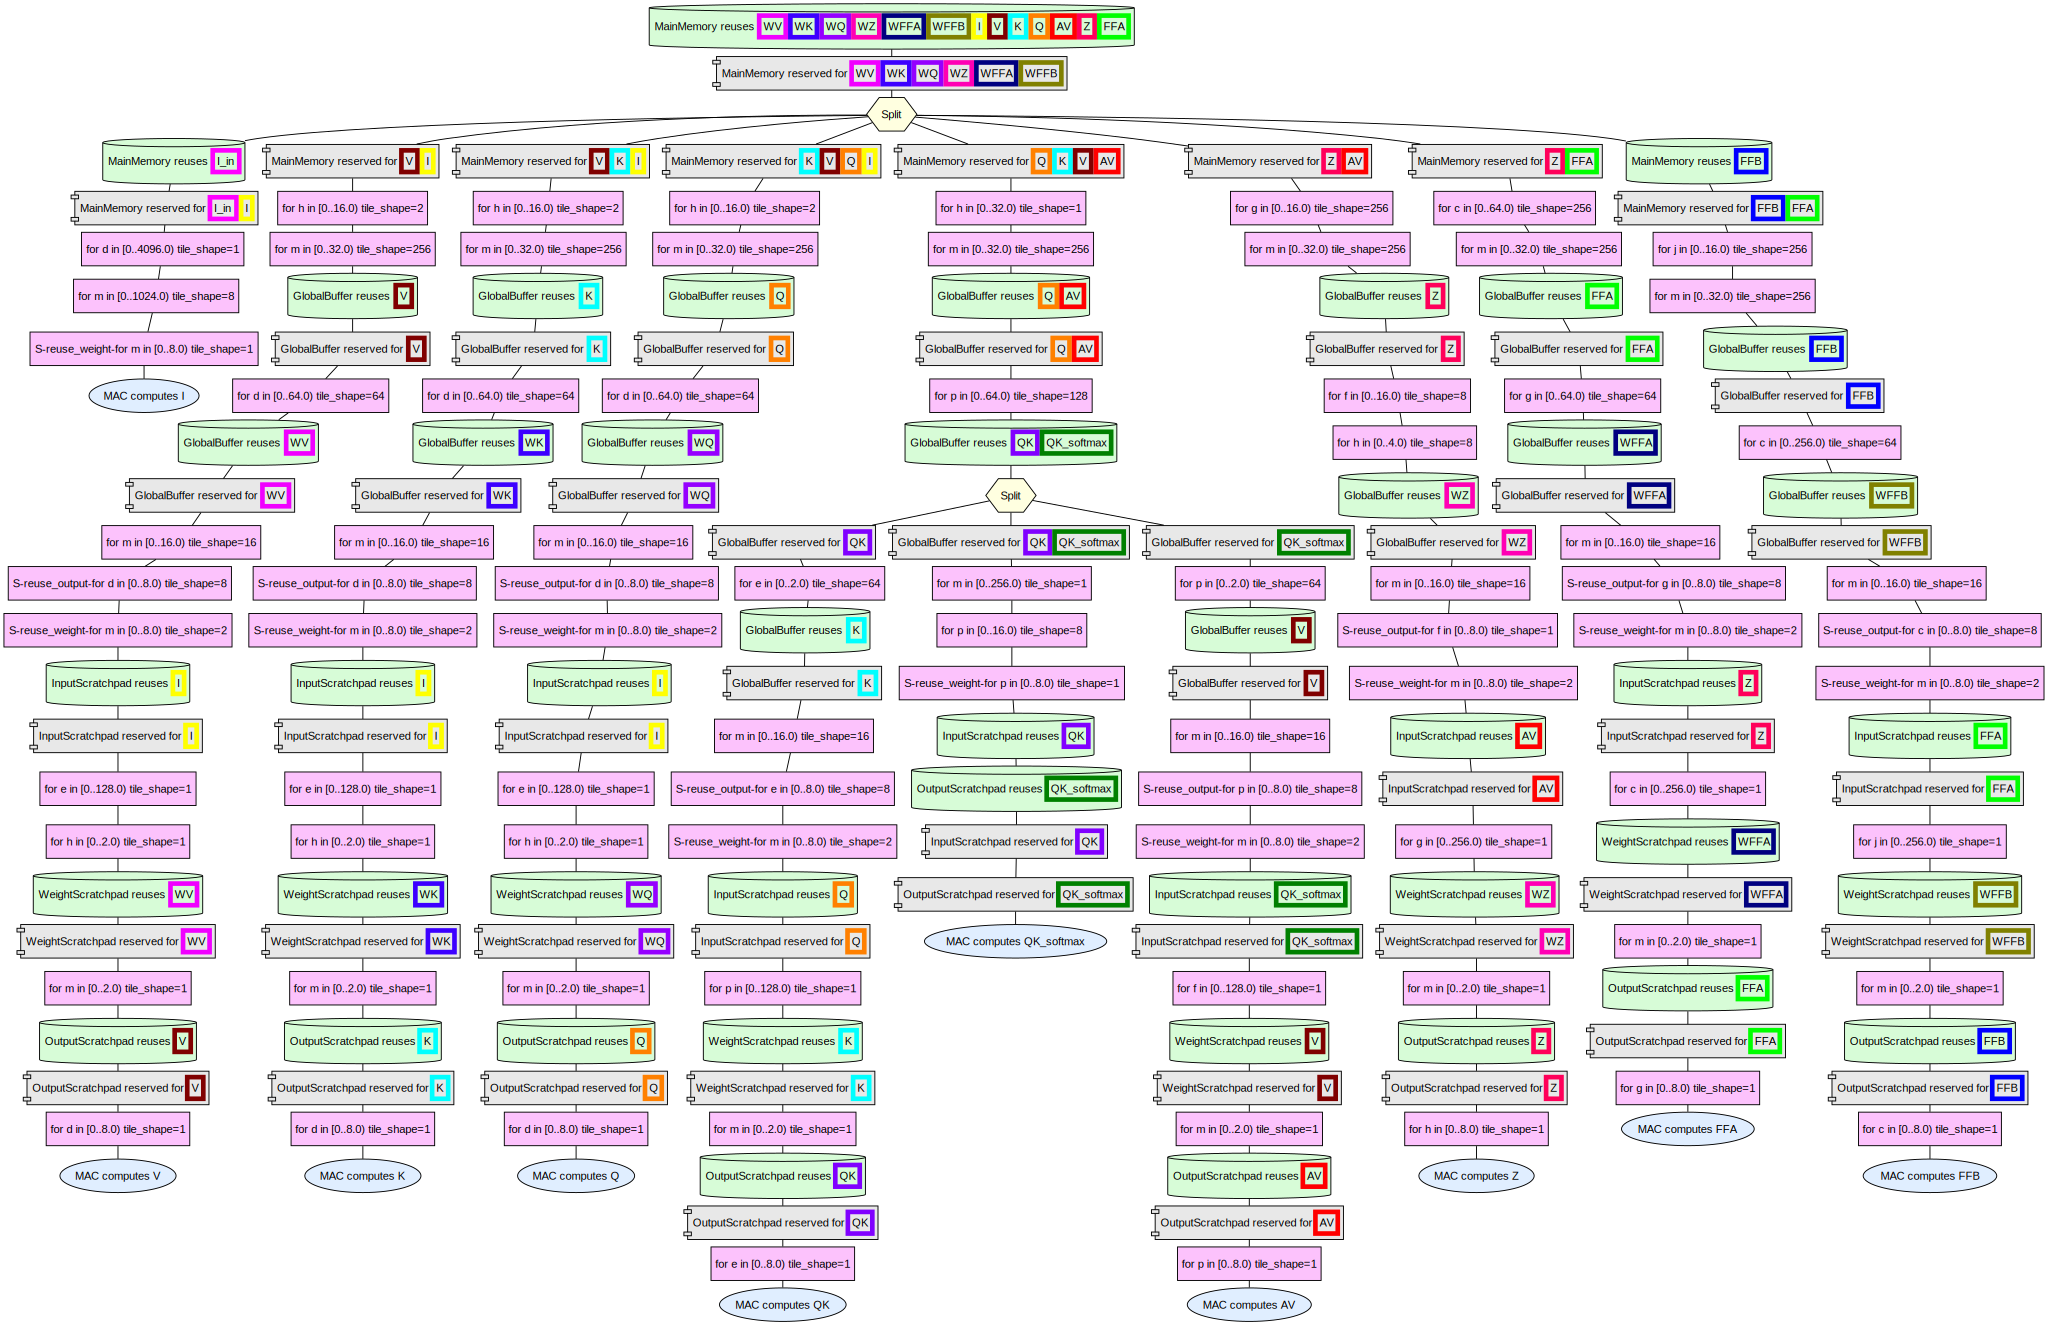

In [14]:
mapping2

In [15]:
print(f'Energy: {mapping2.energy()}J, {mapping2.per_compute().energy()}J/compute')
for k, v in mapping2.per_compute().energy(per_component=True).items():
    print(f'\t{k}: {v}J/compute')

print(f'Latency: {mapping2.latency()}s, {mapping2.per_compute().latency()}s/compute')
for k, v in mapping2.per_compute().latency(per_component=True).items():
    print(f'\t{k}: {v}s/compute')

Energy: 115.0236974815312J, 5.225489339051963e-11J/compute
	MainMemory: 4.477980518589654e-13J/compute
	GlobalBuffer: 5.652830975951254e-12J/compute
	InputScratchpad: 1.4996972029169477e-11J/compute
	WeightScratchpad: 1.512007990862253e-11J/compute
	OutputScratchpad: 1.5310671515457795e-11J/compute
	MAC: 7.265409094596154e-13J/compute
Latency: 173.16183958761394s, 7.866686330923093e-11s/compute
	MainMemory: 1.6681777270308173e-11s/compute
	MAC: 7.86668646890476e-11s/compute
	InputScratchpad: 1.0916945515984655e-13s/compute
	OutputScratchpad: 2.1049985756207978e-13s/compute
	GlobalBuffer: 1.962920248929132e-12s/compute
	WeightScratchpad: 1.473148317741868e-13s/compute
